# Low-Resolution Correlation Geometry Diagnostic

This notebook checks whether the shifted-center lagged conditioning sets are selecting points that are highly correlated with the current target under the true advection covariance.

Main comparisons:

1. At time `t`, compare max-min nearest neighbors with the top correlation neighbors.
2. At time `t-1`, compare three lagged candidate sets for a current target `x`:
   - current-centered local lag reuse
   - parallel-shifted version of the `t` nearest-neighbor set
   - fresh nearest neighbors around the predicted upstream center

The goal is diagnostic, not fitting: this uses the analytic covariance implied by the simulation parameters.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

try:
    from GEMS_TCO import orderings as _orderings
except Exception as exc:
    _orderings = None
    print("WARNING: could not import GEMS_TCO.orderings; using slow NumPy fallback.")
    print(type(exc).__name__, exc)

print("SRC:", _src)
print("orderings module:", _orderings is not None)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
orderings module: True


## Settings


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 2

MM_COND_NUMBER = 100
TOP_K = 8
MIN_ORDER_POS = 40
MAX_TARGETS = None  # None = all eligible targets; set e.g. 500 for faster smoke tests.
SEED = 42

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

# True/predicted lag-1 eastward offsets. Negative advec_lon means upstream is eastward.
TRUE_ADVEC_LON_LIST = [-0.10, -0.126, -0.16, -0.25]
PRED_LAG1_LON_OFFSETS = [0.10, 0.126, 0.16, 0.20, 0.25]

print(f"low-res step: lat={DELTA_LAT:.3f}, lon={DELTA_LON:.3f}")
print("predicted offsets in lon cells:", [round(v / DELTA_LON, 3) for v in PRED_LAG1_LON_OFFSETS])


low-res step: lat=0.176, lon=0.126
predicted offsets in lon cells: [0.794, 1.0, 1.27, 1.587, 1.984]


## Helpers


In [3]:
def build_target_grid(lat_range=LAT_RANGE, lon_range=LON_RANGE):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = np.round(lat0 + np.arange(n_lat) * DELTA_LAT, 4)
    lons = np.round(lon0 + np.arange(n_lon) * DELTA_LON, 4)
    g_lat, g_lon = np.meshgrid(lats, lons, indexing="ij")
    coords = np.column_stack([g_lat.ravel(), g_lon.ravel()])
    return lats, lons, coords

def greedy_maxmin_order(coords):
    # Slow fallback used only if the project C++ max-min routine is unavailable.
    n = coords.shape[0]
    order = np.empty(n, dtype=np.int64)
    order[0] = 0
    chosen = np.zeros(n, dtype=bool)
    chosen[0] = True
    d2_min = np.sum((coords - coords[0]) ** 2, axis=1)
    for i in range(1, n):
        d2_min[chosen] = -1.0
        j = int(np.argmax(d2_min))
        order[i] = j
        chosen[j] = True
        d2_new = np.sum((coords - coords[j]) ** 2, axis=1)
        d2_min = np.minimum(d2_min, d2_new)
    return order

def fallback_find_nns_l2(ordered_coords, max_nn):
    n = ordered_coords.shape[0]
    out = []
    for i in range(n):
        if i == 0:
            out.append(np.array([], dtype=np.int64))
            continue
        prev = ordered_coords[:i]
        d2 = np.sum((prev - ordered_coords[i]) ** 2, axis=1)
        k = min(max_nn, i)
        idx = np.argpartition(d2, k - 1)[:k]
        idx = idx[np.argsort(d2[idx])]
        out.append(idx.astype(np.int64))
    return out

def compute_grid_ordering(coords, mm_cond_number=MM_COND_NUMBER):
    if _orderings is not None:
        ord_mm = _orderings.maxmin_cpp(coords)
        nns = _orderings.find_nns_l2(locs=coords[ord_mm], max_nn=mm_cond_number)
    else:
        ord_mm = greedy_maxmin_order(coords)
        nns = fallback_find_nns_l2(coords[ord_mm], mm_cond_number)
    return np.asarray(ord_mm, dtype=np.int64), nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return np.array([
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"]),
    ], dtype=np.float64)

def latent_corr_current_to_candidate(target_coord, cand_coords, dt, true_dict):
    # dt = target_time - candidate_time. For lag-1 candidate, dt=1.
    p = true_to_log_params(true_dict)
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    dlat = target_coord[0] - cand_coords[:, 0]
    dlon = target_coord[1] - cand_coords[:, 1]
    u_lat = dlat - p[4] * dt
    u_lon = dlon - p[5] * dt
    dist = np.sqrt((u_lat ** 2) * phi3 + (u_lon ** 2) + (dt ** 2) * phi4 + 1e-12)
    return np.exp(-dist * phi2)

def nearest_grid_indices(coords, query_coords):
    # Brute-force Euclidean nearest on this small low-res grid.
    query_coords = np.asarray(query_coords, dtype=np.float64)
    if query_coords.ndim == 1:
        query_coords = query_coords[None, :]
    d2 = ((query_coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2)
    return np.argmin(d2, axis=1).astype(np.int64)

def build_shift_lookup(ordered_coords, lag1_lon_offset, multiplier=1.0):
    lats = ordered_coords[:, 0]
    lons = ordered_coords[:, 1]
    lon_min, lon_max = float(lons.min()), float(lons.max())
    target_lons = lons + multiplier * abs(lag1_lon_offset)
    outside = (target_lons < lon_min) | (target_lons > lon_max)
    q = np.column_stack([lats, target_lons])
    lookup = nearest_grid_indices(ordered_coords, q)
    lookup[outside] = np.arange(len(ordered_coords), dtype=np.int64)[outside]
    return lookup

def clean_unique(seq, exclude=(), k=TOP_K):
    exclude = set(int(x) for x in exclude)
    out = []
    seen = set()
    for x in seq:
        x = int(x)
        if x in exclude or x in seen:
            continue
        seen.add(x)
        out.append(x)
        if len(out) >= k:
            break
    return np.array(out, dtype=np.int64)

def topk_corr_indices(corr, k=TOP_K, exclude=()):
    corr2 = corr.copy()
    for idx in exclude:
        if 0 <= int(idx) < len(corr2):
            corr2[int(idx)] = -np.inf
    k = min(k, np.isfinite(corr2).sum())
    idx = np.argpartition(-corr2, k - 1)[:k]
    idx = idx[np.argsort(-corr2[idx])]
    return idx.astype(np.int64)

def ranks_from_corr(corr):
    order = np.argsort(-corr)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(corr) + 1)
    return ranks

def set_stats(set_idx, corr, top_idx):
    set_idx = np.asarray(set_idx, dtype=np.int64)
    if len(set_idx) == 0:
        return {"mean_corr": np.nan, "median_corr": np.nan, "min_corr": np.nan, "overlap_topk": 0.0, "mean_rank": np.nan, "mean_rank_pct": np.nan}
    ranks = ranks_from_corr(corr)
    return {
        "mean_corr": float(np.mean(corr[set_idx])),
        "median_corr": float(np.median(corr[set_idx])),
        "min_corr": float(np.min(corr[set_idx])),
        "overlap_topk": float(len(set(set_idx).intersection(set(top_idx))) / max(len(top_idx), 1)),
        "mean_rank": float(np.mean(ranks[set_idx])),
        "mean_rank_pct": float(np.mean(ranks[set_idx]) / len(corr)),
    }


## Build Grid And Max-Min Ordering


In [4]:
lats, lons, grid_coords = build_target_grid()
ord_mm, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
ordered_coords = grid_coords[ord_mm]
N = len(ordered_coords)

eligible = np.arange(max(MIN_ORDER_POS, TOP_K + 1), N, dtype=np.int64)
if MAX_TARGETS is not None and len(eligible) > MAX_TARGETS:
    rng = np.random.default_rng(SEED)
    eligible = np.sort(rng.choice(eligible, size=MAX_TARGETS, replace=False))

print(f"grid: {len(lats)} x {len(lons)} = {N:,} spatial points")
print(f"eligible targets: {len(eligible):,} / {N:,}")
print("first/last lat:", lats[0], lats[-1], "first/last lon:", lons[0], lons[-1])


grid: 29 x 80 = 2,320 spatial points
eligible targets: 2,280 / 2,320
first/last lat: -3.0 1.928 first/last lon: 121.0 130.954


## Same-Time Diagnostic: Max-Min NN vs Correlation Top-K


In [5]:
same_rows = []
true_dict = {**TRUE_DICT}
for i in eligible:
    target = ordered_coords[i]
    # Same-time Vecchia candidates are previous points in max-min order.
    admissible = np.arange(i, dtype=np.int64)
    cand_coords = ordered_coords[admissible]
    corr_adm = latent_corr_current_to_candidate(target, cand_coords, dt=0.0, true_dict=true_dict)

    top_local = topk_corr_indices(corr_adm, TOP_K)
    top_idx = admissible[top_local]
    nn_idx = clean_unique(nns_grid[i], k=TOP_K)

    # Convert full-grid corr vector for common stats.
    corr_full = np.full(N, -np.inf, dtype=np.float64)
    corr_full[admissible] = corr_adm
    same_rows.append({
        "target_order_idx": int(i),
        "target_lat": float(target[0]),
        "target_lon": float(target[1]),
        "topk": TOP_K,
        "nn_overlap_corr_topk": len(set(nn_idx).intersection(set(top_idx))) / TOP_K,
        "nn_mean_corr": float(np.mean(corr_full[nn_idx])),
        "corr_topk_mean_corr": float(np.mean(corr_full[top_idx])),
        "nn_mean_rank_pct": set_stats(nn_idx, corr_full, top_idx)["mean_rank_pct"],
    })

same_df = pd.DataFrame(same_rows)
print("Same-time summary: does spatial NN approximate top correlation neighbors?")
display(same_df.describe(percentiles=[0.1, 0.5, 0.9]).T)


Same-time summary: does spatial NN approximate top correlation neighbors?


,count,mean,std,min,10%,50%,90%,max
target_order_idx,2280.0,1179.500000,658.323629,40.000000,267.900000,1179.500000,2091.100000,2319.000000
target_lat,2280.0,-0.536077,1.470393,-3.000000,-2.648000,-0.536000,1.576000,1.928000
target_lon,2280.0,125.977497,2.904599,121.000000,122.008000,126.040000,129.946000,130.954000
topk,2280.0,8.000000,0.000000,8.000000,8.000000,8.000000,8.000000,8.000000
nn_overlap_corr_topk,2280.0,0.896601,0.088869,0.625000,0.750000,0.875000,1.000000,1.000000
nn_mean_corr,2280.0,0.452188,0.139956,0.019249,0.234088,0.505436,0.580748,0.583094
corr_topk_mean_corr,2280.0,0.455391,0.140033,0.019253,0.240816,0.512723,0.583094,0.583094
nn_mean_rank_pct,2280.0,0.002083,0.000147,0.001940,0.001940,0.002047,0.002263,0.002748


## Lag-1 Diagnostic: Local Reuse vs Parallel Shift vs Fresh Shift-Center


In [6]:
lag_rows = []
pair_rows = []

for true_advec_lon in TRUE_ADVEC_LON_LIST:
    true_dict = {**TRUE_DICT, "advec_lon": float(true_advec_lon)}
    true_shift = abs(true_advec_lon)
    for pred_offset in PRED_LAG1_LON_OFFSETS:
        center_lookup = build_shift_lookup(ordered_coords, pred_offset, multiplier=1.0)

        for i in eligible:
            target = ordered_coords[i]
            # For diagnostic truth, lag-1 candidates can be anywhere on the previous-time grid.
            corr_full = latent_corr_current_to_candidate(target, ordered_coords, dt=1.0, true_dict=true_dict)
            corr_top = topk_corr_indices(corr_full, TOP_K)

            t_nn = clean_unique(nns_grid[i], k=TOP_K)
            local_reuse = t_nn

            # Old idea: take t-neighbor coordinates, shift the whole cloud eastward by predicted offset, then snap to grid.
            q_parallel = ordered_coords[t_nn].copy()
            q_parallel[:, 1] += abs(pred_offset)
            outside = (q_parallel[:, 1] < ordered_coords[:, 1].min()) | (q_parallel[:, 1] > ordered_coords[:, 1].max())
            parallel_shift = nearest_grid_indices(ordered_coords, q_parallel)
            parallel_shift[outside] = t_nn[outside]
            parallel_shift = clean_unique(parallel_shift, k=TOP_K)

            # Current successful idea: move the center first, then choose fresh NN around that center.
            center_idx = int(center_lookup[i])
            fresh_shift = clean_unique([center_idx, *list(nns_grid[center_idx])], exclude=(), k=TOP_K)

            stats = {}
            for set_name, idx in [
                ("local_reuse_current_center", local_reuse),
                ("parallel_shift_t_nn", parallel_shift),
                ("fresh_shift_center", fresh_shift),
            ]:
                st = set_stats(idx, corr_full, corr_top)
                row = {
                    "true_advec_lon": float(true_advec_lon),
                    "true_lag1_shift": float(true_shift),
                    "pred_lag1_offset": float(pred_offset),
                    "pred_offset_cells": float(pred_offset / DELTA_LON),
                    "offset_abs_error": float(abs(pred_offset - true_shift)),
                    "target_order_idx": int(i),
                    "set_name": set_name,
                    **st,
                }
                lag_rows.append(row)
                stats[set_name] = st

            pair_rows.append({
                "true_advec_lon": float(true_advec_lon),
                "true_lag1_shift": float(true_shift),
                "pred_lag1_offset": float(pred_offset),
                "target_order_idx": int(i),
                "fresh_gt_local_mean_corr": stats["fresh_shift_center"]["mean_corr"] > stats["local_reuse_current_center"]["mean_corr"],
                "fresh_gt_parallel_mean_corr": stats["fresh_shift_center"]["mean_corr"] > stats["parallel_shift_t_nn"]["mean_corr"],
                "parallel_gt_local_mean_corr": stats["parallel_shift_t_nn"]["mean_corr"] > stats["local_reuse_current_center"]["mean_corr"],
                "fresh_minus_local_mean_corr": stats["fresh_shift_center"]["mean_corr"] - stats["local_reuse_current_center"]["mean_corr"],
                "fresh_minus_parallel_mean_corr": stats["fresh_shift_center"]["mean_corr"] - stats["parallel_shift_t_nn"]["mean_corr"],
            })

lag_df = pd.DataFrame(lag_rows)
pair_df = pd.DataFrame(pair_rows)
print("lag_df rows:", len(lag_df), "pair_df rows:", len(pair_df))


lag_df rows: 136800 pair_df rows: 45600


## Summaries


In [7]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

lag_summary = (
    lag_df
    .groupby(["true_advec_lon", "pred_lag1_offset", "set_name"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        mean_corr=("mean_corr", "mean"),
        median_corr=("mean_corr", "median"),
        p90_p10_corr=("mean_corr", p90_p10),
        overlap_topk_mean=("overlap_topk", "mean"),
        mean_rank_pct=("mean_rank_pct", "mean"),
        offset_abs_error=("offset_abs_error", "first"),
        pred_offset_cells=("pred_offset_cells", "first"),
    )
    .reset_index()
)

pair_summary = (
    pair_df
    .groupby(["true_advec_lon", "pred_lag1_offset"], sort=True)
    .agg(
        n=("target_order_idx", "count"),
        fresh_gt_local_rate=("fresh_gt_local_mean_corr", "mean"),
        fresh_gt_parallel_rate=("fresh_gt_parallel_mean_corr", "mean"),
        parallel_gt_local_rate=("parallel_gt_local_mean_corr", "mean"),
        fresh_minus_local_mean=("fresh_minus_local_mean_corr", "mean"),
        fresh_minus_parallel_mean=("fresh_minus_parallel_mean_corr", "mean"),
    )
    .reset_index()
)

print("Lag-1 set quality summary. Higher mean_corr/overlap is better; lower mean_rank_pct is better.")
display(lag_summary.sort_values(["true_advec_lon", "pred_lag1_offset", "mean_corr"], ascending=[True, True, False]))

print("Pairwise win rates for fresh shifted-center.")
display(pair_summary)


Lag-1 set quality summary. Higher mean_corr/overlap is better; lower mean_rank_pct is better.


,true_advec_lon,pred_lag1_offset,set_name,n,mean_corr,median_corr,p90_p10_corr,overlap_topk_mean,mean_rank_pct,offset_abs_error,pred_offset_cells
0,-0.250,0.100,fresh_shift_center,2280,0.380123,0.416041,0.207195,0.428564,0.012136,0.150,0.793651
2,-0.250,0.100,parallel_shift_t_nn,2280,0.357449,0.390540,0.228423,0.335417,0.009915,0.150,0.793651
1,-0.250,0.100,local_reuse_current_center,2280,0.323826,0.350064,0.191185,0.230428,0.011880,0.150,0.793651
3,-0.250,0.126,fresh_shift_center,2280,0.380123,0.416041,0.207195,0.428564,0.012136,0.124,1.000000
5,-0.250,0.126,parallel_shift_t_nn,2280,0.357449,0.390540,0.228423,0.335417,0.009915,0.124,1.000000
4,-0.250,0.126,local_reuse_current_center,2280,0.323826,0.350064,0.191185,0.230428,0.011880,0.124,1.000000
6,-0.250,0.160,fresh_shift_center,2280,0.380618,0.416041,0.202352,0.429715,0.011856,0.090,1.269841
8,-0.250,0.160,parallel_shift_t_nn,2280,0.357310,0.390540,0.228423,0.333553,0.009916,0.090,1.269841
7,-0.250,0.160,local_reuse_current_center,2280,0.323826,0.350064,0.191185,0.230428,0.011880,0.090,1.269841
9,-0.250,0.200,fresh_shift_center,2280,0.396282,0.435850,0.222220,0.484430,0.011531,0.050,1.587302


Pairwise win rates for fresh shifted-center.


,true_advec_lon,pred_lag1_offset,n,fresh_gt_local_rate,fresh_gt_parallel_rate,parallel_gt_local_rate,fresh_minus_local_mean,fresh_minus_parallel_mean
0,-0.250,0.100,2280,0.698246,0.521491,0.922368,0.056297,0.022674
1,-0.250,0.126,2280,0.698246,0.521491,0.922368,0.056297,0.022674
2,-0.250,0.160,2280,0.706140,0.526316,0.922807,0.056792,0.023308
3,-0.250,0.200,2280,0.793421,0.624123,0.903947,0.072456,0.027508
4,-0.250,0.250,2280,0.793421,0.624123,0.903947,0.072456,0.027508
5,-0.160,0.100,2280,0.603509,0.520175,0.879386,0.045660,0.027400
6,-0.160,0.126,2280,0.603509,0.520175,0.879386,0.045660,0.027400
7,-0.160,0.160,2280,0.611842,0.522807,0.880263,0.046268,0.027930
8,-0.160,0.200,2280,0.705702,0.610526,0.707018,0.038281,0.025276
9,-0.160,0.250,2280,0.705702,0.610526,0.707018,0.038281,0.025276


## Plots


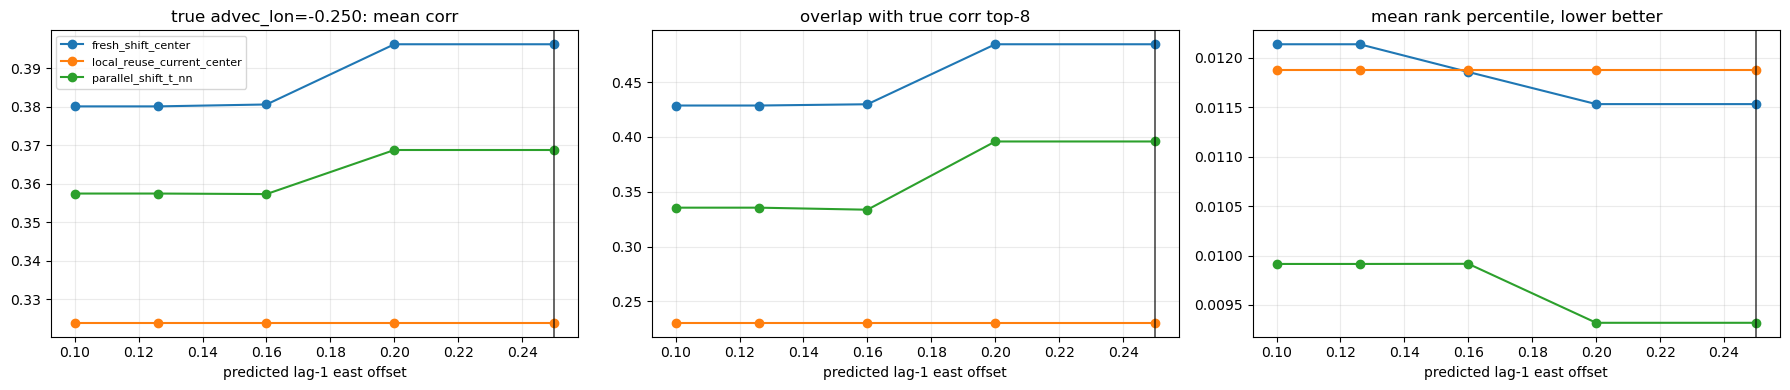

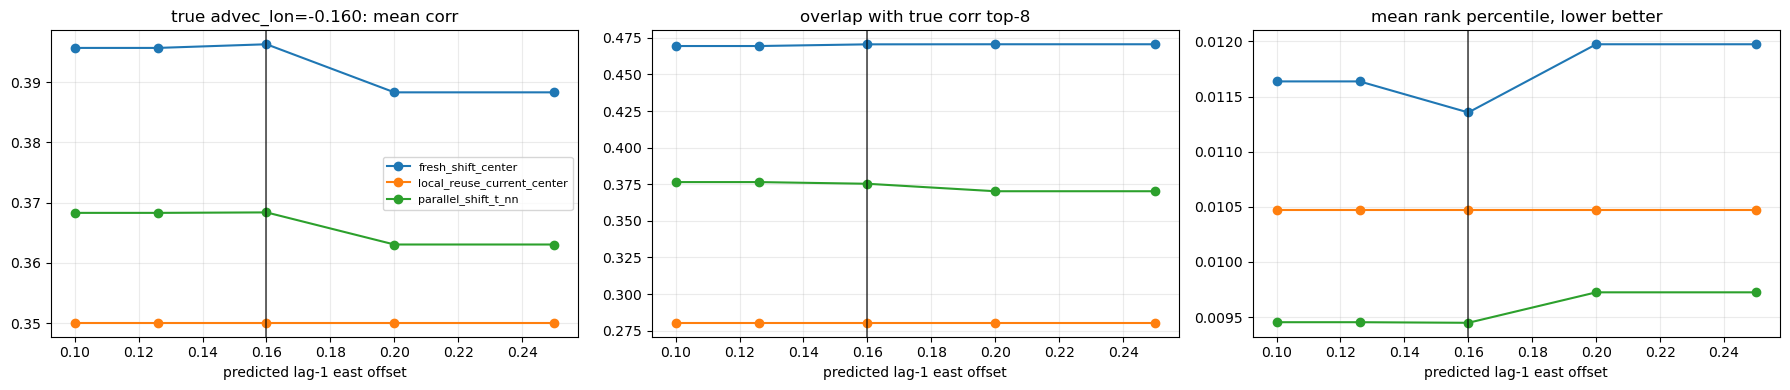

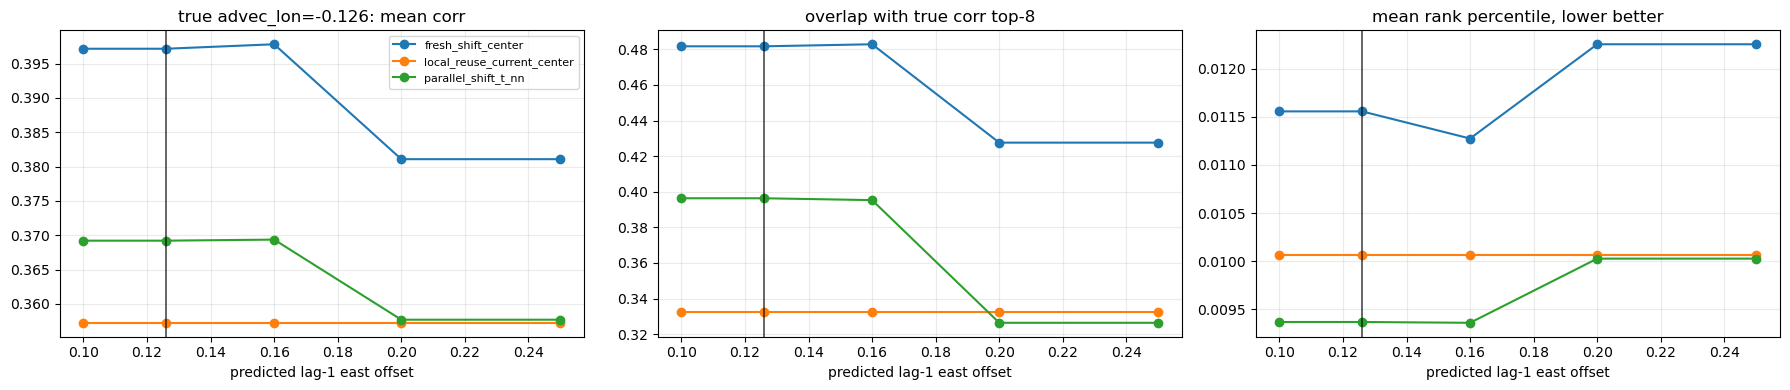

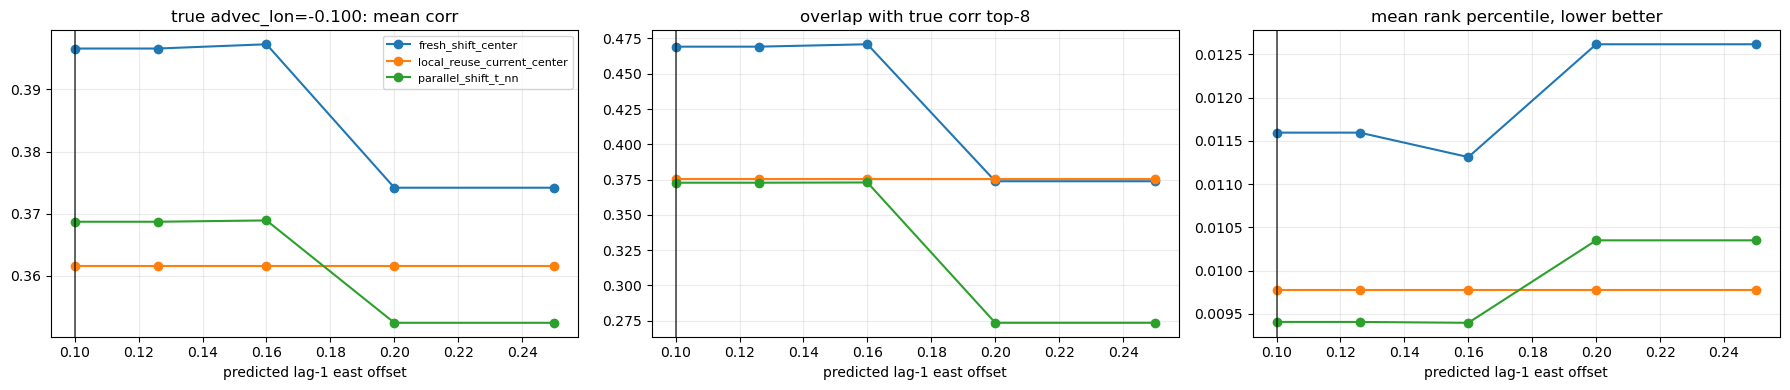

In [8]:
for true_lon, sub in lag_summary.groupby("true_advec_lon", sort=True):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for set_name, ss in sub.groupby("set_name"):
        ss = ss.sort_values("pred_lag1_offset")
        axes[0].plot(ss["pred_lag1_offset"], ss["mean_corr"], marker="o", label=set_name)
        axes[1].plot(ss["pred_lag1_offset"], ss["overlap_topk_mean"], marker="o", label=set_name)
        axes[2].plot(ss["pred_lag1_offset"], ss["mean_rank_pct"], marker="o", label=set_name)
    for ax in axes:
        ax.axvline(abs(true_lon), color="black", linewidth=1.2, alpha=0.7)
        ax.set_xlabel("predicted lag-1 east offset")
        ax.grid(alpha=0.25)
    axes[0].set_title(f"true advec_lon={true_lon:.3f}: mean corr")
    axes[1].set_title("overlap with true corr top-8")
    axes[2].set_title("mean rank percentile, lower better")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Single-Target Inspection


In [9]:
INSPECT_TRUE_ADVEC_LON = -0.126
INSPECT_PRED_OFFSET = 0.126
INSPECT_TARGET_ORDER_IDX = int(eligible[len(eligible) // 2])

true_dict = {**TRUE_DICT, "advec_lon": INSPECT_TRUE_ADVEC_LON}
center_lookup = build_shift_lookup(ordered_coords, INSPECT_PRED_OFFSET, multiplier=1.0)
i = INSPECT_TARGET_ORDER_IDX
target = ordered_coords[i]
corr_same = np.full(N, -np.inf)
admissible = np.arange(i, dtype=np.int64)
corr_same[admissible] = latent_corr_current_to_candidate(target, ordered_coords[admissible], dt=0.0, true_dict=true_dict)
corr_lag1 = latent_corr_current_to_candidate(target, ordered_coords, dt=1.0, true_dict=true_dict)

t_nn = clean_unique(nns_grid[i], k=TOP_K)
q_parallel = ordered_coords[t_nn].copy(); q_parallel[:, 1] += abs(INSPECT_PRED_OFFSET)
parallel = clean_unique(nearest_grid_indices(ordered_coords, q_parallel), k=TOP_K)
center_idx = int(center_lookup[i])
fresh = clean_unique([center_idx, *list(nns_grid[center_idx])], k=TOP_K)

def inspect_table(label, idx, corr):
    return pd.DataFrame({
        "set": label,
        "order_idx": idx,
        "lat": ordered_coords[idx, 0],
        "lon": ordered_coords[idx, 1],
        "corr": corr[idx],
        "rank": ranks_from_corr(corr)[idx],
    })

inspect_df = pd.concat([
    inspect_table("same_t_nn", t_nn, corr_same),
    inspect_table("same_t_corr_top", topk_corr_indices(corr_same, TOP_K), corr_same),
    inspect_table("lag1_local_reuse", t_nn, corr_lag1),
    inspect_table("lag1_parallel_shift_t_nn", parallel, corr_lag1),
    inspect_table("lag1_fresh_shift_center", fresh, corr_lag1),
    inspect_table("lag1_corr_top", topk_corr_indices(corr_lag1, TOP_K), corr_lag1),
])

print("target order idx:", i, "target coord:", target)
display(inspect_df.sort_values(["set", "rank"]))


target order idx: 1180 target coord: [  0.696 128.686]


,set,order_idx,lat,lon,corr,rank
0,lag1_corr_top,2234,0.696,128.812,0.567414,1
1,lag1_corr_top,2241,0.520,128.812,0.552317,2
2,lag1_corr_top,746,0.696,128.938,0.522917,3
3,lag1_corr_top,1180,0.696,128.686,0.522917,4
4,lag1_corr_top,1211,0.520,128.938,0.510671,5
5,lag1_corr_top,29,0.520,128.686,0.510671,6
6,lag1_corr_top,1170,0.696,129.064,0.428547,7
7,lag1_corr_top,834,0.696,128.560,0.428547,8
0,lag1_fresh_shift_center,2234,0.696,128.812,0.567414,1
1,lag1_fresh_shift_center,746,0.696,128.938,0.522917,3


## How To Read This

If the shifted-center method is working for the reason we suspect, the lag-1 `fresh_shift_center` set should have:

- higher mean correlation with the current target than `parallel_shift_t_nn`
- higher overlap with the lag-1 true correlation top-8
- lower mean rank percentile
- high `fresh_gt_parallel_rate` in the pairwise summary

If `parallel_shift_t_nn` performs similarly, then the old idea of moving the t-neighbor cloud was not intrinsically bad; the earlier failure may have come from implementation details, boundary handling, or budget allocation. If `fresh_shift_center` wins clearly, then the important operation is not preserving the t-neighbor geometry, but re-centering the lagged search and reselecting neighbors under that lagged geometry.